In [ ]:
import numpy as np
import pandas as pd
import os

import kagglehub

# Download latest version
path = kagglehub.dataset_download("soumyop/synthetic-employee-performance-dataset")

# print("Path to dataset files:", path)

# List all files in the downloaded folder
files = os.listdir(path)
# print("Files found:", files)

# Locate the data file (e.g., the first .csv file) and load it
employee_csv = [f for f in files if f.endswith(".csv")][0]
file_full_path = os.path.join(path, employee_csv)

df = pd.read_csv(file_full_path)

# Save a copy directly into your current project folder
df.to_csv("employee_performance.csv", index=False)
# print("Saved successfully as employee_performance.csv")

In [24]:
#department-wise average performance
avg_perform = df.groupby("Department")["Performance Score"].mean()
print(avg_perform)

print("\n")
#top 10 employees based on performance score
top_10 = df.sort_values(by="Performance Score", ascending=False).head(10)
print(top_10)

print("\n")
#employees with attendance below 75%
low_attend = df[df["Attendance(%)"] < 75]
print(low_attend.sum())


Department
AI & Data Science         73.473552
Customer Support          73.209900
Finance                   73.747667
Human Resources           73.088524
Information Technology    73.203594
Marketing                 73.366694
Operations                73.578672
Sales                     73.544862
Name: Performance Score, dtype: float64


       E_ID             Name  Age              Department                Role  \
4803  E4804      Janhvi Modi   35        Customer Support   Support Executive   
2470  E2471  Ikshita Scindia   24  Information Technology     DevOps Engineer   
4779  E4780    Garima Sahani   27                 Finance          Accountant   
4764  E4765      Saket Batra   25       AI & Data Science         ML Engineer   
3260  E3261    Triveni Gupta   50  Information Technology   Software Engineer   
1430  E1431   Paritosh Rathi   34                 Finance   Financial Analyst   
1738  E1739    Atishay Kamat   54              Operations  Operations Manager   
2263  E2264

Department
AI & Data Science         808
Customer Support          502
Finance                   480
Human Resources           515
Information Technology    871
Marketing                 484
Operations                723
Sales                     617
Name: E_ID, dtype: int64


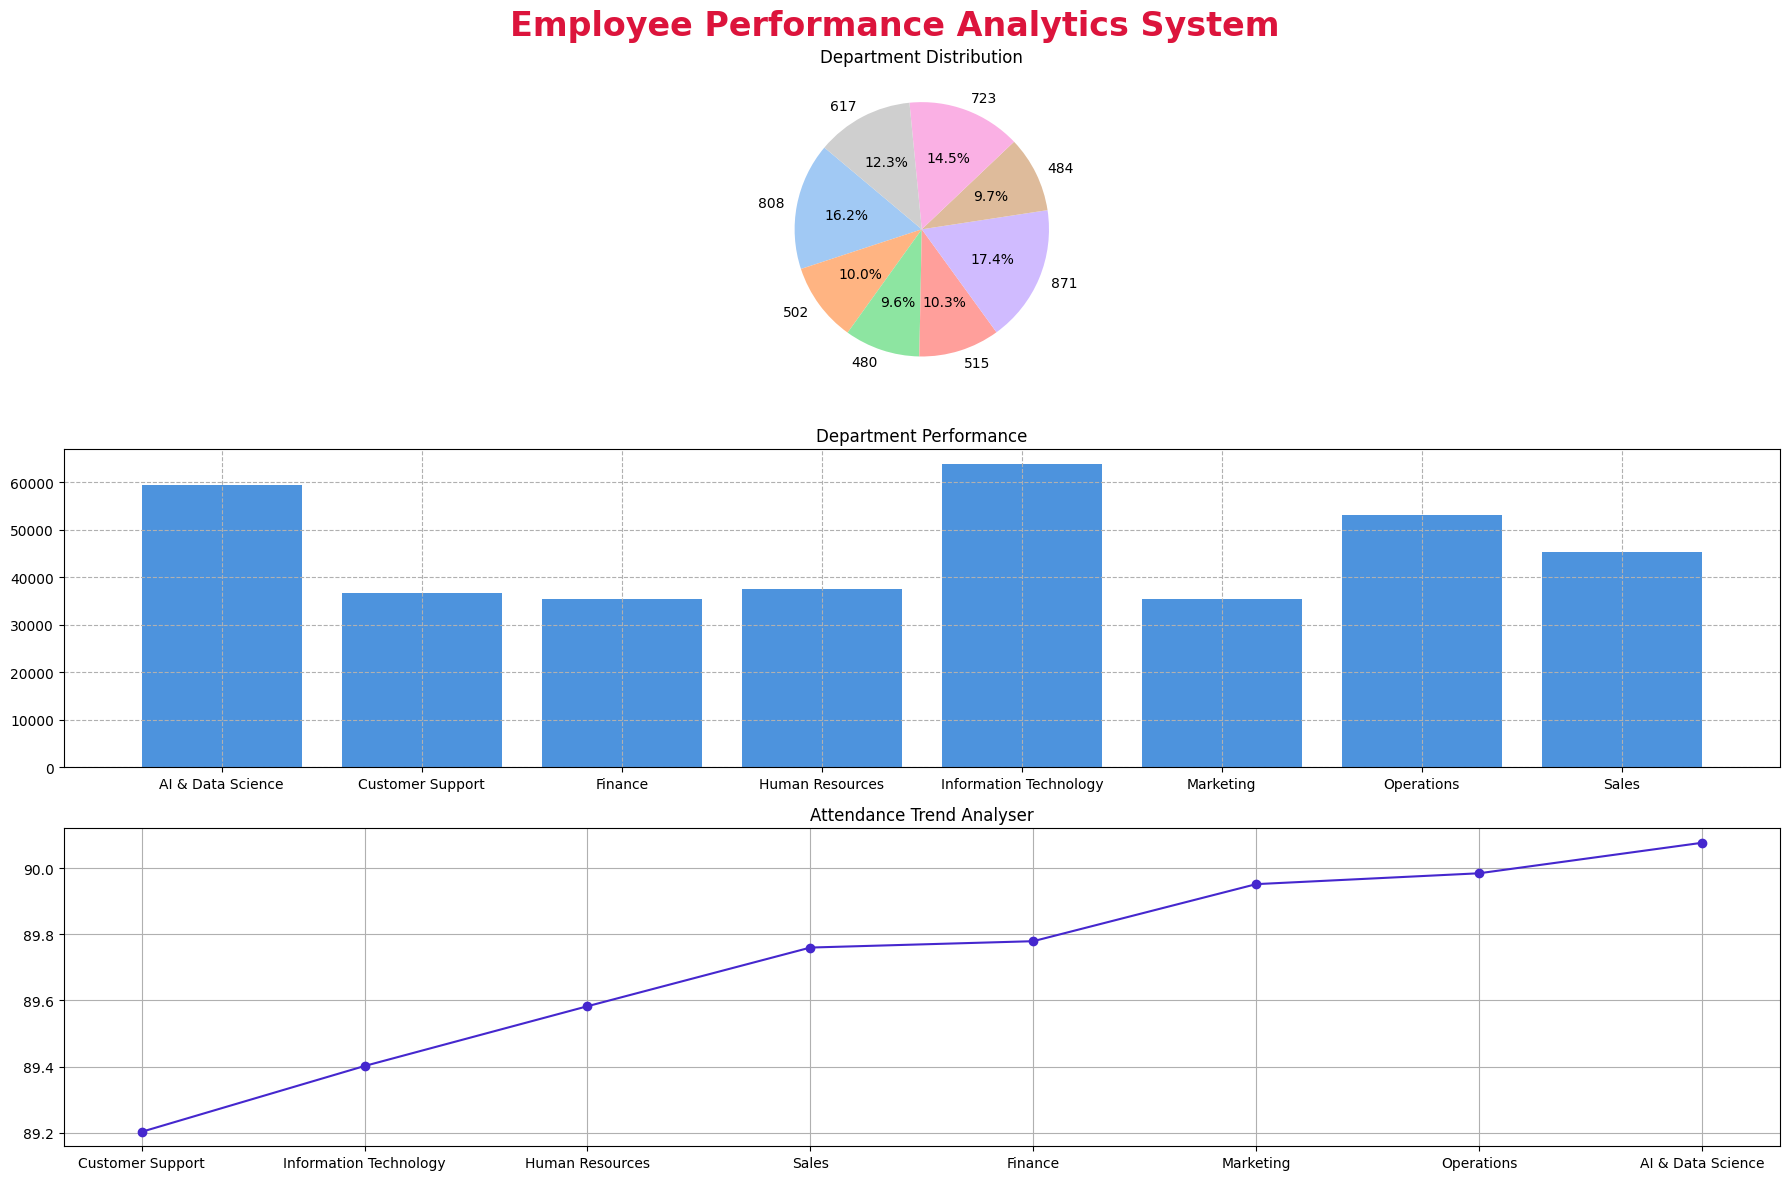

In [87]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,1, figsize = (18,12))
fig.suptitle("Employee Performance Analytics System", fontweight = "bold", fontsize = 24, color = "crimson")

#performance comparision chart (deptartment wise)
dept_score = df.groupby("Department")["Performance Score"].sum()
axes[1].bar(dept_score.index , dept_score.values, alpha = 0.85 , color = "#2e80d8")
axes[1].set_title("Department Performance")
axes[1].set_xlable = ("Department")
axes[1].set_ylable = ("Performance Score")
axes[1].grid(True, linestyle = "--")

#Department distribution
dept_size = df.groupby("Department")["E_ID"].count()
axes[0].pie(
    dept_size,
        labels=dept_size,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel')
)
axes[0].set_title("Department Distribution")
print(dept_size)


#Attendance trend
sort_attend = df.groupby("Department")["Attendance(%)"].mean().sort_values()
axes[2].plot(
    sort_attend.index,
    sort_attend.values,
    marker = "o",
    color = "#4527ce"
)
axes[2].set_title("Attendance Trend Analyser")
axes[2].set_xlable = ("Department")
axes[2].set_ylable = ("Attendance(%)")
axes[2].grid(True)


plt.tight_layout()
plt.show()
